In [1]:
import sys
sys.executable

'/Users/leilasoltani/Desktop/Online_Courses/Projects/sentiment_analysis/myproject/bin/python'

In [22]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Download latest version
file_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", file_path)

Path to dataset files: /Users/leilasoltani/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [5]:

import os
from re import sub
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import time


In [23]:
csv_file = os.path.join(file_path, "IMDB Dataset.csv")
df = pd.read_csv(csv_file)


print("First 5 records:", df.head())

First 5 records:                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [24]:

# ==================== SETUP ====================

def clean_text(text):
    text = str(text).lower()
    text = sub(r"<.*?>", "", text)
    text = sub(r"http\S+|www\S+", "", text)
    text = sub(r"[^a-z\s]", "", text)
    text = sub(r"\s+", " ", text).strip()
    return text


print("=" * 70)
print("COMPREHENSIVE METRICS EVALUATION - ALL 4 METHODS")
print("=" * 70)

# Load and prepare data
csv_file = os.path.join(file_path, "IMDB Dataset.csv")
df = pd.read_csv(csv_file)
df['cleaned_review'] = df['review'].apply(clean_text)

X = df['cleaned_review']
y = df['sentiment'].map({'negative': 0, 'positive': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.8, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"✓ Data prepared: {len(X_train):,} train, {len(X_test):,} test")



COMPREHENSIVE METRICS EVALUATION - ALL 4 METHODS
✓ Data prepared: 40,000 train, 10,000 test


In [25]:

# ==================== TRAIN ALL MODELS ====================

print("\n" + "=" * 70)
print("TRAINING ALL 4 METHODS")
print("=" * 70)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM': LinearSVC(max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Get probabilities if available (for ROC-AUC)
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_pred_proba = model.decision_function(X_test_tfidf)
    else:
        y_pred_proba = None
    
    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # ROC-AUC (if probabilities available)
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None
    
    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    
    # Store results
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'precision_neg': precision_per_class[0],
        'precision_pos': precision_per_class[1],
        'recall_neg': recall_per_class[0],
        'recall_pos': recall_per_class[1],
        'f1_neg': f1_per_class[0],
        'f1_pos': f1_per_class[1],
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'train_time': train_time
    }
    
    print(f"✓ {name}: Accuracy={accuracy:.4f}, F1={f1:.4f}")



TRAINING ALL 4 METHODS

Training Logistic Regression...
✓ Logistic Regression: Accuracy=0.8553, F1=0.8559

Training Naive Bayes...
✓ Naive Bayes: Accuracy=0.8238, F1=0.8253

Training Random Forest...
✓ Random Forest: Accuracy=0.8266, F1=0.8273

Training SVM...
✓ SVM: Accuracy=0.8560, F1=0.8569


In [26]:

# ==================== COMPREHENSIVE METRICS TABLE ====================

print("\n" + "=" * 70)
print("COMPREHENSIVE METRICS COMPARISON")
print("=" * 70)

# Create comprehensive metrics dataframe
metrics_data = []

for name in results.keys():
    r = results[name]
    metrics_data.append({
        'Method': name,
        'Accuracy': r['accuracy'],
        'Precision (Pos)': r['precision_pos'],
        'Recall (Pos)': r['recall_pos'],
        'F1-Score (Pos)': r['f1_pos'],
        'Precision (Neg)': r['precision_neg'],
        'Recall (Neg)': r['recall_neg'],
        'F1-Score (Neg)': r['f1_neg'],
        'ROC-AUC': r['roc_auc'] if r['roc_auc'] else np.nan,
        'Train Time (s)': r['train_time']
    })

metrics_df = pd.DataFrame(metrics_data)

# Sort by F1-Score (positive class)
metrics_df = metrics_df.sort_values('F1-Score (Pos)', ascending=False)

print("\n" + metrics_df.to_string(index=False))

# Save to CSV
metrics_df.to_csv('comprehensive_metrics_all_methods.csv', index=False)
print("\n✓ Saved: 'comprehensive_metrics_all_methods.csv'")




COMPREHENSIVE METRICS COMPARISON

             Method  Accuracy  Precision (Pos)  Recall (Pos)  F1-Score (Pos)  Precision (Neg)  Recall (Neg)  F1-Score (Neg)  ROC-AUC  Train Time (s)
                SVM    0.8560         0.851362        0.8626        0.856944         0.860762        0.8494        0.855043 0.932853        0.510926
Logistic Regression    0.8553         0.852550        0.8592        0.855862         0.858093        0.8514        0.854733 0.933091        0.128007
      Random Forest    0.8266         0.824137        0.8304        0.827256         0.829101        0.8228        0.825939 0.904394        9.114046
        Naive Bayes    0.8238         0.818325        0.8324        0.825302         0.829467        0.8152        0.822272 0.903045        0.005043

✓ Saved: 'comprehensive_metrics_all_methods.csv'



CREATING COMPREHENSIVE VISUALIZATIONS
✓ Saved: 'all_metrics_comparison.png'


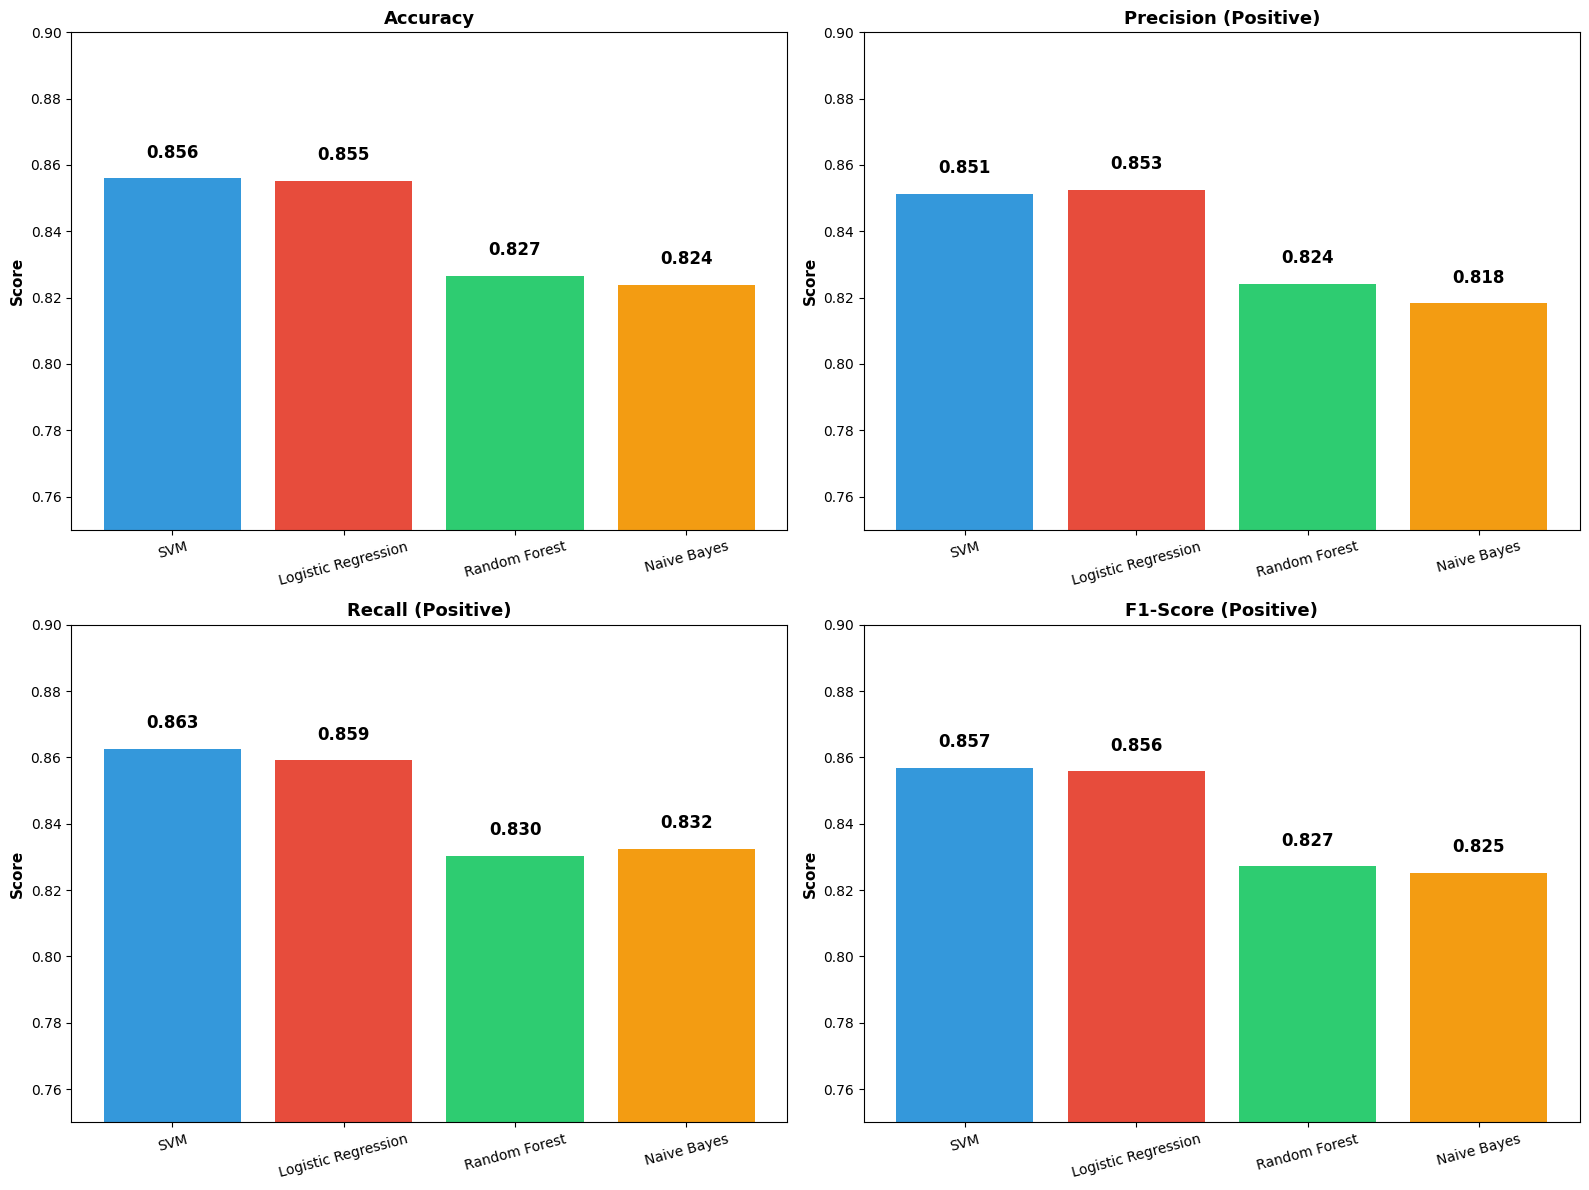

✓ Saved: 'precision_recall_tradeoff.png'


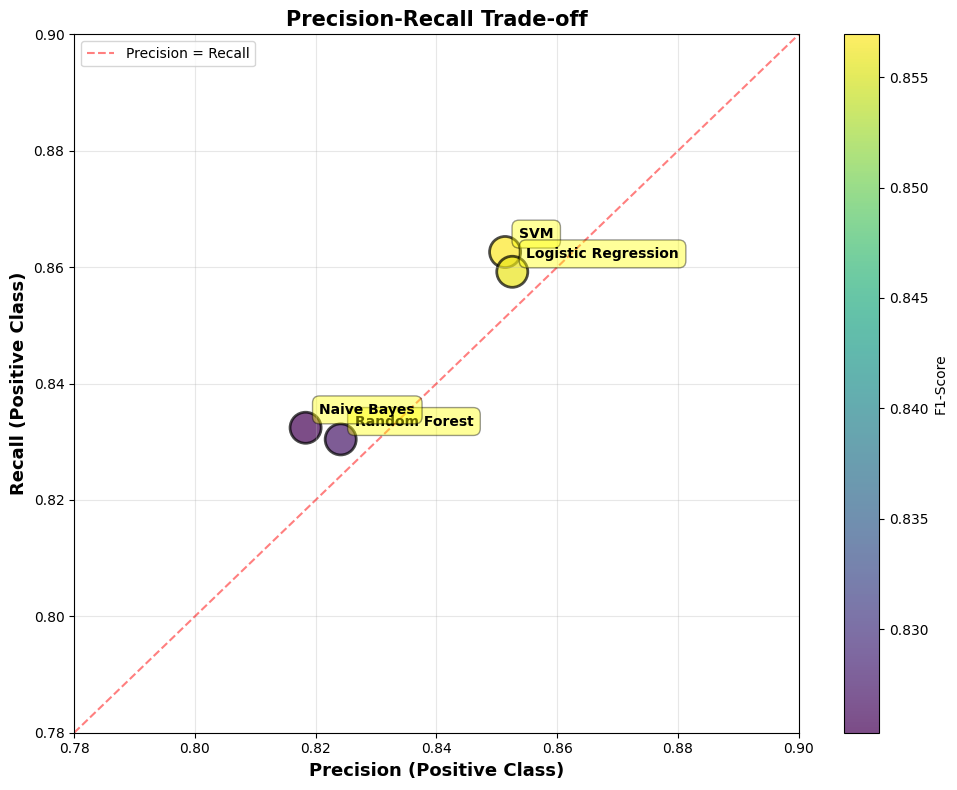

✓ Saved: 'per_class_metrics.png'


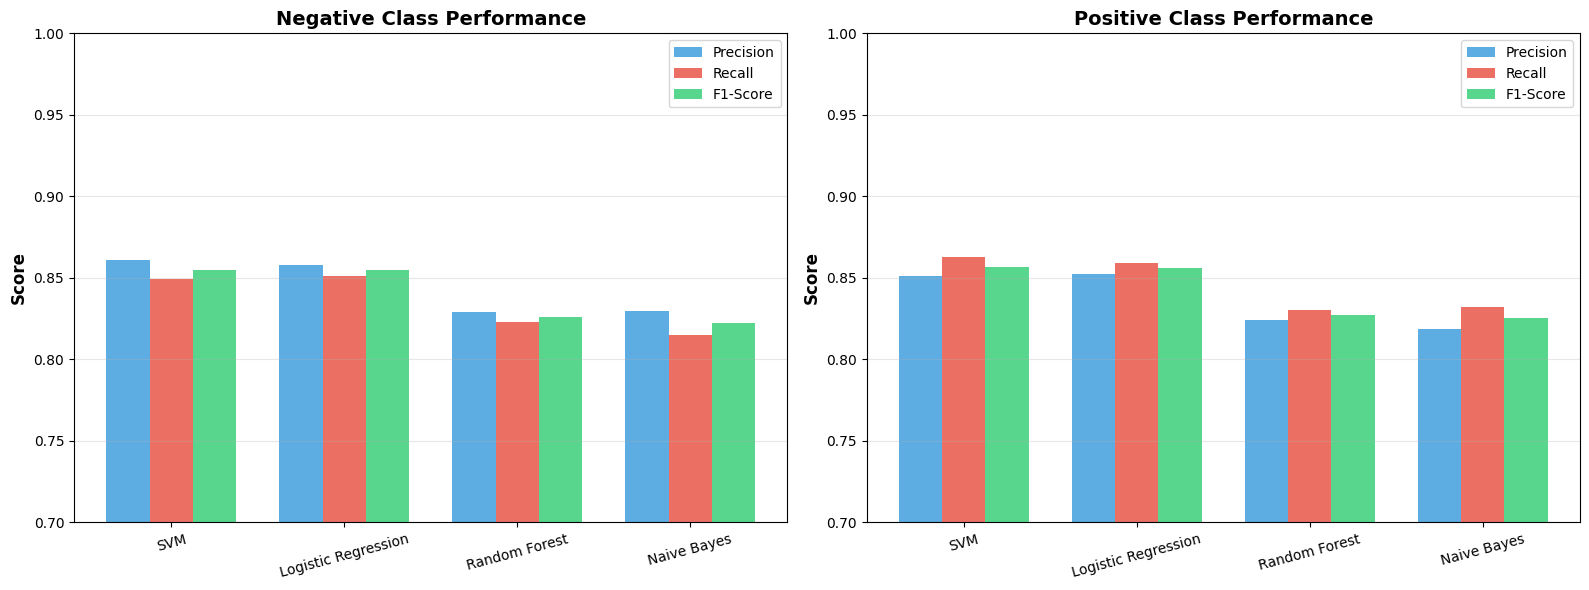

✓ Saved: 'roc_curves_all_methods.png'


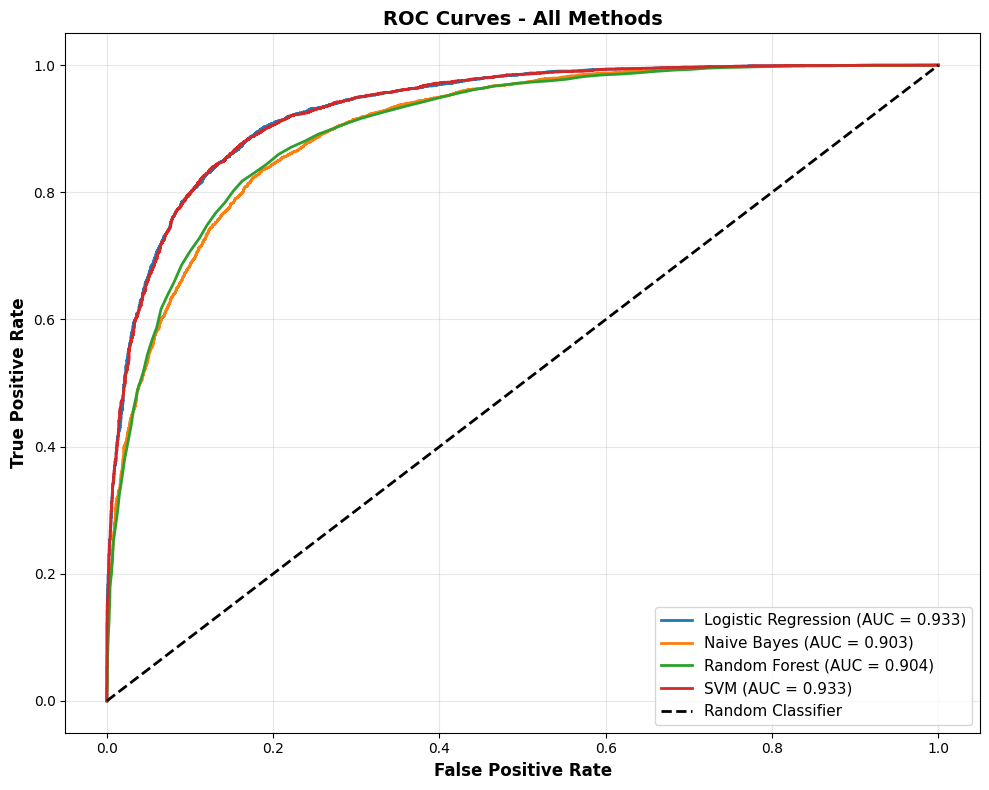

In [27]:

# ==================== METRICS VISUALIZATION ====================

print("\n" + "=" * 70)
print("CREATING COMPREHENSIVE VISUALIZATIONS")
print("=" * 70)

# Figure 1: All Key Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = [
    ('Accuracy', 'Accuracy'),
    ('Precision (Pos)', 'Precision (Positive)'),
    ('Recall (Pos)', 'Recall (Positive)'),
    ('F1-Score (Pos)', 'F1-Score (Positive)')
]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric_col, metric_name) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    bars = ax.bar(metrics_df['Method'], metrics_df[metric_col], color=colors)
    ax.set_ylabel('Score', fontweight='bold', fontsize=11)
    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.set_ylim([0.75, 0.90])
    ax.tick_params(axis='x', rotation=15)
    
    # Add value labels
    for i, (method, value) in enumerate(zip(metrics_df['Method'], metrics_df[metric_col])):
        ax.text(i, value + 0.005, f'{value:.3f}', 
               ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('all_metrics_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 'all_metrics_comparison.png'")
plt.show()


# Figure 2: Precision vs Recall (Positive Class)
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(metrics_df['Precision (Pos)'], 
                    metrics_df['Recall (Pos)'],
                    s=500, 
                    c=metrics_df['F1-Score (Pos)'], 
                    cmap='viridis', 
                    alpha=0.7, 
                    edgecolors='black',
                    linewidth=2)

ax.set_xlabel('Precision (Positive Class)', fontweight='bold', fontsize=13)
ax.set_ylabel('Recall (Positive Class)', fontweight='bold', fontsize=13)
ax.set_title('Precision-Recall Trade-off', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0.78, 0.90])
ax.set_ylim([0.78, 0.90])

# Add diagonal line (precision = recall)
ax.plot([0.78, 0.90], [0.78, 0.90], 'r--', alpha=0.5, label='Precision = Recall')

# Add labels for each method
for i, method in enumerate(metrics_df['Method']):
    ax.annotate(method, 
               (metrics_df['Precision (Pos)'].iloc[i], 
                metrics_df['Recall (Pos)'].iloc[i]),
               xytext=(10, 10), 
               textcoords='offset points',
               fontsize=10,
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.4))

plt.colorbar(scatter, ax=ax, label='F1-Score')
ax.legend()
plt.tight_layout()
plt.savefig('precision_recall_tradeoff.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 'precision_recall_tradeoff.png'")
plt.show()


# Figure 3: Per-Class Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Negative class metrics
ax1 = axes[0]
width = 0.25
x = np.arange(len(metrics_df))

bars1 = ax1.bar(x - width, metrics_df['Precision (Neg)'], width, 
                label='Precision', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x, metrics_df['Recall (Neg)'], width, 
                label='Recall', color='#e74c3c', alpha=0.8)
bars3 = ax1.bar(x + width, metrics_df['F1-Score (Neg)'], width, 
                label='F1-Score', color='#2ecc71', alpha=0.8)

ax1.set_ylabel('Score', fontweight='bold', fontsize=12)
ax1.set_title('Negative Class Performance', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df['Method'], rotation=15)
ax1.legend()
ax1.set_ylim([0.7, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Positive class metrics
ax2 = axes[1]
bars1 = ax2.bar(x - width, metrics_df['Precision (Pos)'], width, 
                label='Precision', color='#3498db', alpha=0.8)
bars2 = ax2.bar(x, metrics_df['Recall (Pos)'], width, 
                label='Recall', color='#e74c3c', alpha=0.8)
bars3 = ax2.bar(x + width, metrics_df['F1-Score (Pos)'], width, 
                label='F1-Score', color='#2ecc71', alpha=0.8)

ax2.set_ylabel('Score', fontweight='bold', fontsize=12)
ax2.set_title('Positive Class Performance', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_df['Method'], rotation=15)
ax2.legend()
ax2.set_ylim([0.7, 1.0])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 'per_class_metrics.png'")
plt.show()


# Figure 4: ROC Curves (for models with probabilities)
fig, ax = plt.subplots(figsize=(10, 8))

for name in results.keys():
    if results[name]['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
        auc = results[name]['roc_auc']
        ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
ax.set_title('ROC Curves - All Methods', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_all_methods.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 'roc_curves_all_methods.png'")
plt.show()



In [28]:

# ==================== DETAILED CLASSIFICATION REPORTS ====================

print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 70)

for name in results.keys():
    print(f"\n{'='*70}")
    print(f"{name}")
    print(f"{'='*70}")
    print(classification_report(y_test, results[name]['predictions'], 
                                target_names=['Negative', 'Positive']))




DETAILED CLASSIFICATION REPORTS

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      5000
    Positive       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


Naive Bayes
              precision    recall  f1-score   support

    Negative       0.83      0.82      0.82      5000
    Positive       0.82      0.83      0.83      5000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000


Random Forest
              precision    recall  f1-score   support

    Negative       0.83      0.82      0.83      5000
    Positive       0.82      0.83      0.83      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83   

In [12]:

# ==================== BEST MODEL BY EACH METRIC ====================

print("\n" + "=" * 70)
print("WINNERS BY METRIC")
print("=" * 70)

winner_accuracy = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
winner_precision = metrics_df.loc[metrics_df['Precision (Pos)'].idxmax()]
winner_recall = metrics_df.loc[metrics_df['Recall (Pos)'].idxmax()]
winner_f1 = metrics_df.loc[metrics_df['F1-Score (Pos)'].idxmax()]

# For ROC-AUC, need to handle NaN
metrics_df_with_auc = metrics_df.dropna(subset=['ROC-AUC'])
if len(metrics_df_with_auc) > 0:
    winner_auc = metrics_df_with_auc.loc[metrics_df_with_auc['ROC-AUC'].idxmax()]
else:
    winner_auc = None

print(f"\n🏆 Best Accuracy:     {winner_accuracy['Method']} ({winner_accuracy['Accuracy']:.4f})")
print(f"🏆 Best Precision:    {winner_precision['Method']} ({winner_precision['Precision (Pos)']:.4f})")
print(f"🏆 Best Recall:       {winner_recall['Method']} ({winner_recall['Recall (Pos)']:.4f})")
print(f"🏆 Best F1-Score:     {winner_f1['Method']} ({winner_f1['F1-Score (Pos)']:.4f})")
if winner_auc is not None:
    print(f"🏆 Best ROC-AUC:      {winner_auc['Method']} ({winner_auc['ROC-AUC']:.4f})")




WINNERS BY METRIC

🏆 Best Accuracy:     SVM (0.8560)
🏆 Best Precision:    Logistic Regression (0.8526)
🏆 Best Recall:       SVM (0.8626)
🏆 Best F1-Score:     SVM (0.8569)
🏆 Best ROC-AUC:      Logistic Regression (0.9331)



CREATING SUMMARY HEATMAP
✓ Saved: 'metrics_heatmap.png'


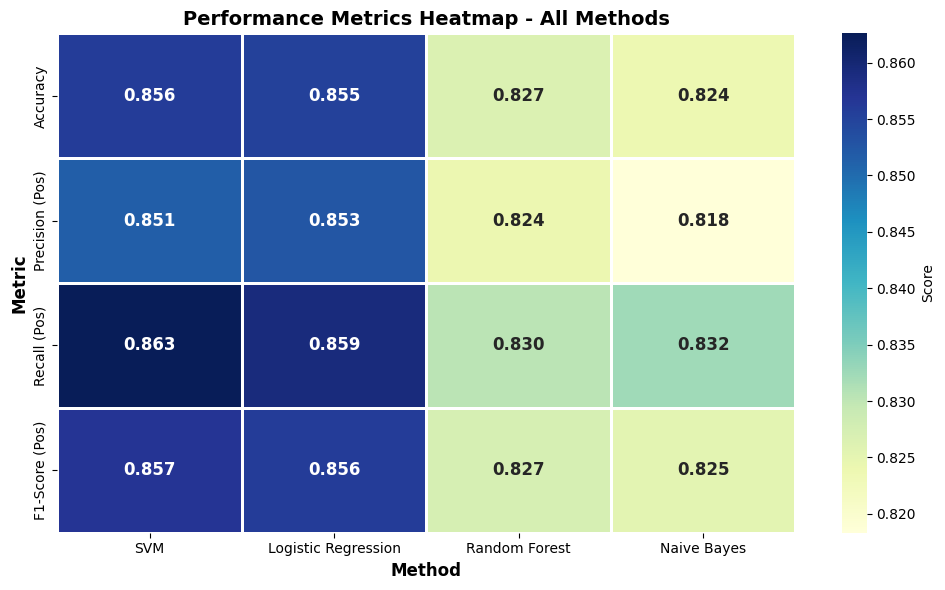

In [29]:

# ==================== SUMMARY HEATMAP ====================

print("\n" + "=" * 70)
print("CREATING SUMMARY HEATMAP")
print("=" * 70)

# Create summary matrix for heatmap
summary_matrix = metrics_df[['Method', 'Accuracy', 'Precision (Pos)', 
                             'Recall (Pos)', 'F1-Score (Pos)']].set_index('Method')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(summary_matrix.T, annot=True, fmt='.3f', cmap='YlGnBu', 
           cbar_kws={'label': 'Score'}, linewidths=1, ax=ax,
           annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Performance Metrics Heatmap - All Methods', 
            fontsize=14, fontweight='bold')
ax.set_ylabel('Metric', fontweight='bold', fontsize=12)
ax.set_xlabel('Method', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 'metrics_heatmap.png'")
plt.show()


In [14]:

# ==================== FINAL SUMMARY ====================

print("\n" + "=" * 70)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("=" * 70)

print(f"""
All 4 methods evaluated on {len(y_test):,} test samples.

Metrics Calculated:
✓ Accuracy
✓ Precision (per class)
✓ Recall (per class)
✓ F1-Score (per class)
✓ ROC-AUC (where applicable)
✓ Confusion Matrix

Best Overall Model (by F1-Score): {winner_f1['Method']}
  • Accuracy:  {winner_f1['Accuracy']:.4f}
  • Precision: {winner_f1['Precision (Pos)']:.4f}
  • Recall:    {winner_f1['Recall (Pos)']:.4f}
  • F1-Score:  {winner_f1['F1-Score (Pos)']:.4f}

Key Insights:
• All models perform similarly (within {(metrics_df['Accuracy'].max() - metrics_df['Accuracy'].min())*100:.2f}%)
• {winner_precision['Method']} has highest precision (fewest false positives)
• {winner_recall['Method']} has highest recall (catches most positives)
• {winner_f1['Method']} provides best balance

Files Created:
✓ comprehensive_metrics_all_methods.csv
✓ all_metrics_comparison.png
✓ precision_recall_tradeoff.png
✓ per_class_metrics.png
✓ roc_curves_all_methods.png
✓ metrics_heatmap.png
""")

print("\n" + "=" * 70)
print("COMPREHENSIVE EVALUATION COMPLETE! 🎉")
print("=" * 70)



COMPREHENSIVE EVALUATION SUMMARY

All 4 methods evaluated on 10,000 test samples.

Metrics Calculated:
✓ Accuracy
✓ Precision (per class)
✓ Recall (per class)
✓ F1-Score (per class)
✓ ROC-AUC (where applicable)
✓ Confusion Matrix

Best Overall Model (by F1-Score): SVM
  • Accuracy:  0.8560
  • Precision: 0.8514
  • Recall:    0.8626
  • F1-Score:  0.8569

Key Insights:
• All models perform similarly (within 3.22%)
• Logistic Regression has highest precision (fewest false positives)
• SVM has highest recall (catches most positives)
• SVM provides best balance

Files Created:
✓ comprehensive_metrics_all_methods.csv
✓ all_metrics_comparison.png
✓ precision_recall_tradeoff.png
✓ per_class_metrics.png
✓ roc_curves_all_methods.png
✓ metrics_heatmap.png


COMPREHENSIVE EVALUATION COMPLETE! 🎉


In [30]:
results

{'Logistic Regression': {'model': LogisticRegression(max_iter=1000, random_state=42),
  'predictions': array([0, 1, 1, ..., 0, 1, 1]),
  'probabilities': array([0.41557385, 0.91721231, 0.85291135, ..., 0.06581203, 0.75365141,
         0.60937685]),
  'accuracy': 0.8553,
  'precision': 0.8525501091486406,
  'recall': 0.8592,
  'f1': 0.8558621376631138,
  'roc_auc': np.float64(0.9330906399999999),
  'precision_neg': np.float64(0.8580931263858093),
  'precision_pos': np.float64(0.8525501091486406),
  'recall_neg': np.float64(0.8514),
  'recall_pos': np.float64(0.8592),
  'f1_neg': np.float64(0.8547334604959341),
  'f1_pos': np.float64(0.8558621376631138),
  'confusion_matrix': array([[4257,  743],
         [ 704, 4296]]),
  'train_time': 0.1280069351196289},
 'Naive Bayes': {'model': MultinomialNB(),
  'predictions': array([0, 1, 1, ..., 0, 1, 1]),
  'probabilities': array([0.40215281, 0.68659867, 0.64718768, ..., 0.22199185, 0.64391583,
         0.54377592]),
  'accuracy': 0.8238,
  'pre

In [31]:
# ==================== PREPARE DATA FOR LINE CHART ====================

print("\n" + "=" * 70)
print("PREPARING DATA FOR LINE CHART")
print("=" * 70)

# Extract metrics from your results dictionary
# Your keys are lowercase: 'accuracy', 'precision', 'recall', 'f1'

methods = list(results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']


PREPARING DATA FOR LINE CHART


In [37]:
for m in methods: 
    print (results[m]['accuracy'])

0.8553
0.8238
0.8266
0.856



PREPARING DATA FOR LINE CHART

Extracted values:
Accuracies:  [0.8553, 0.8238, 0.8266, 0.856]
Precisions:  [0.8525501091486406, 0.8183248132127409, 0.8241365621278285, 0.8513620213185945]
Recalls:     [0.8592, 0.8324, 0.8304, 0.8626]
F1-Scores:   [0.8558621376631138, 0.825302399365457, 0.8272564255827854, 0.8569441684879794]

CREATING LINE CHART

✓ Saved: 'metrics_line_chart.png'


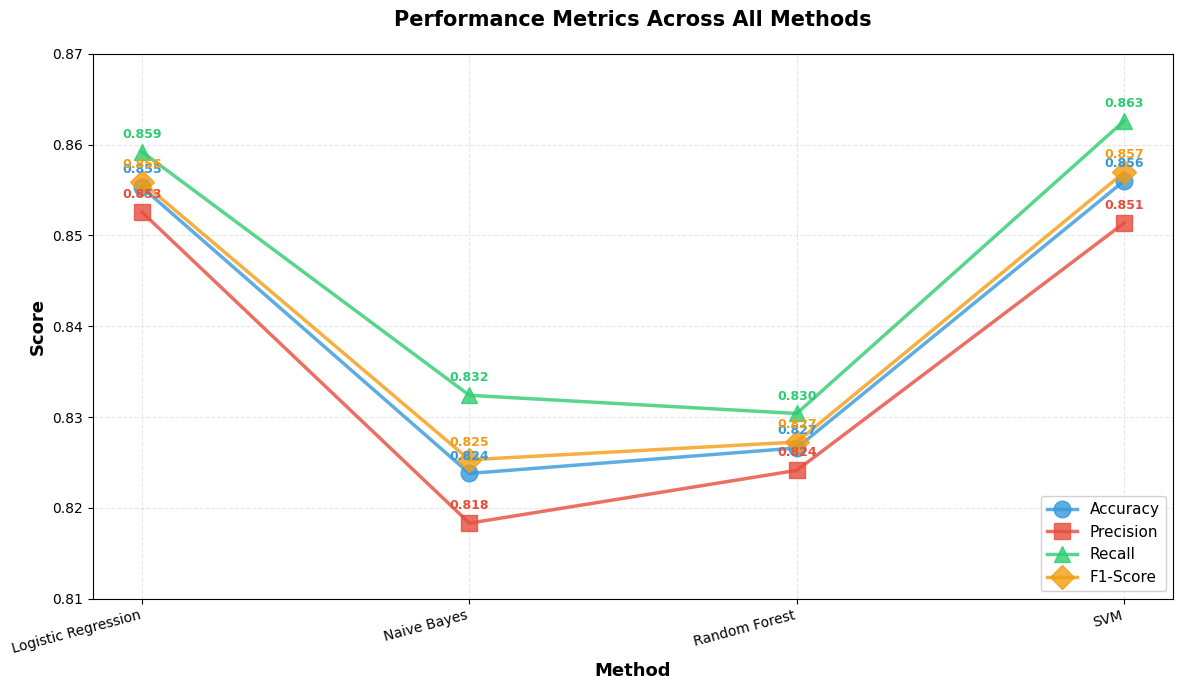

In [41]:
# ==================== PREPARE DATA FOR LINE CHART ====================

print("\n" + "=" * 70)
print("PREPARING DATA FOR LINE CHART")
print("=" * 70)

methods = list(results.keys())

# Extract all metrics using the same pattern that works for you
accuracy_values = [results[m]['accuracy'] for m in methods]
precision_values = [results[m]['precision'] for m in methods]
recall_values = [results[m]['recall'] for m in methods]
f1_values = [results[m]['f1'] for m in methods]

print("\nExtracted values:")
print(f"Accuracies:  {accuracy_values}")
print(f"Precisions:  {precision_values}")
print(f"Recalls:     {recall_values}")
print(f"F1-Scores:   {f1_values}")



# ==================== CREATE LINE CHART ====================

print("\n" + "=" * 70)
print("CREATING LINE CHART")
print("=" * 70)

fig, ax = plt.subplots(figsize=(12, 7))

# Plot each metric as a line
ax.plot(methods, accuracy_values, 
       label='Accuracy',
       color='#3498db',
       marker='o',
       markersize=12,
       linewidth=2.5,
       alpha=0.8)

ax.plot(methods, precision_values, 
       label='Precision',
       color='#e74c3c',
       marker='s',
       markersize=12,
       linewidth=2.5,
       alpha=0.8)

ax.plot(methods, recall_values, 
       label='Recall',
       color='#2ecc71',
       marker='^',
       markersize=12,
       linewidth=2.5,
       alpha=0.8)

ax.plot(methods, f1_values, 
       label='F1-Score',
       color='#f39c12',
       marker='D',
       markersize=12,
       linewidth=2.5,
       alpha=0.8)

# Add value labels for Accuracy
for i, (method, value) in enumerate(zip(methods, accuracy_values)):
    ax.annotate(f'{value:.3f}', 
               xy=(i, value),
               xytext=(0, 10),
               textcoords='offset points',
               ha='center',
               fontsize=9,
               fontweight='bold',
               color='#3498db')

# Add value labels for Precision
for i, (method, value) in enumerate(zip(methods, precision_values)):
    ax.annotate(f'{value:.3f}', 
               xy=(i, value),
               xytext=(0, 10),
               textcoords='offset points',
               ha='center',
               fontsize=9,
               fontweight='bold',
               color='#e74c3c')

# Add value labels for Recall
for i, (method, value) in enumerate(zip(methods, recall_values)):
    ax.annotate(f'{value:.3f}', 
               xy=(i, value),
               xytext=(0, 10),
               textcoords='offset points',
               ha='center',
               fontsize=9,
               fontweight='bold',
               color='#2ecc71')

# Add value labels for F1-Score
for i, (method, value) in enumerate(zip(methods, f1_values)):
    ax.annotate(f'{value:.3f}', 
               xy=(i, value),
               xytext=(0, 10),
               textcoords='offset points',
               ha='center',
               fontsize=9,
               fontweight='bold',
               color='#f39c12')

# Customize the chart
ax.set_xlabel('Method', fontweight='bold', fontsize=13)
ax.set_ylabel('Score', fontweight='bold', fontsize=13)
ax.set_title('Performance Metrics Across All Methods', 
            fontsize=15, fontweight='bold', pad=20)
ax.set_ylim([0.81, 0.87])
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)

# Rotate x-axis labels for better readability
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig('metrics_line_chart.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 'metrics_line_chart.png'")
plt.show()


ALTERNATIVE VIEW: SEPARATE SUBPLOTS PER METRIC
✓ Saved: 'metrics_line_chart_subplots.png'


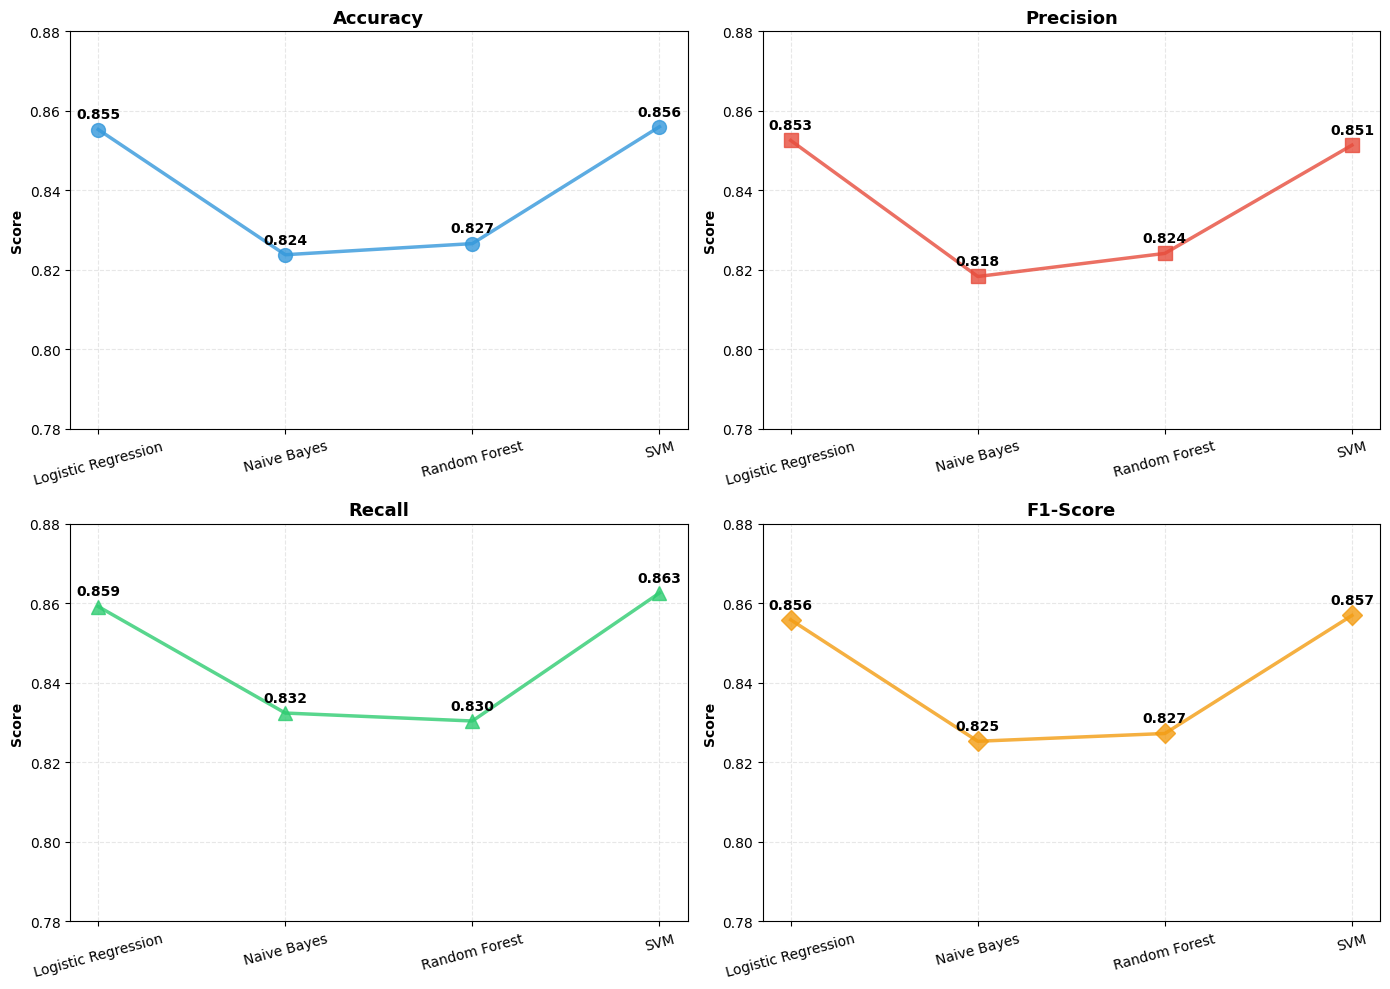

In [47]:
# ==================== ALTERNATIVE: GROUPED BY METRIC ====================

print("\n" + "=" * 70)
print("ALTERNATIVE VIEW: SEPARATE SUBPLOTS PER METRIC")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define metrics with their display names and dictionary keys
metrics_mapping = [
    ('Accuracy', 'accuracy'),
    ('Precision', 'precision'),
    ('Recall', 'recall'),
    ('F1-Score', 'f1')
]

colors = {
    'Accuracy': '#3498db',
    'Precision': '#e74c3c',
    'Recall': '#2ecc71',
    'F1-Score': '#f39c12'
}

markers = {
    'Accuracy': 'o',
    'Precision': 's',
    'Recall': '^',
    'F1-Score': 'D'
}

for idx, (metric_display, metric_key) in enumerate(metrics_mapping):
    ax = axes[idx]
    
    # Get values using the correct lowercase key
    values = [results[method][metric_key] for method in methods]
    
    ax.plot(methods, values, 
           color=colors[metric_display],
           marker=markers[metric_display],
           markersize=10,
           linewidth=2.5,
           alpha=0.8)
    
    # Add value labels
    for i, (method, value) in enumerate(zip(methods, values)):
        ax.annotate(f'{value:.3f}', 
                   xy=(i, value),
                   xytext=(0, 8),
                   textcoords='offset points',
                   ha='center',
                   fontsize=10,
                   fontweight='bold')
    
    ax.set_title(metric_display, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_ylim([0.78, 0.88])
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('metrics_line_chart_subplots.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 'metrics_line_chart_subplots.png'")
plt.show()

In [49]:
# ==================== STATISTICS ====================

print("\n" + "=" * 70)
print("STATISTICS")
print("=" * 70)

# Define metrics with their display names and dictionary keys
metrics_mapping = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1-Score': 'f1'
}

# Find best method for each metric
print("\nBest method for each metric:")
for metric_display, metric_key in metrics_mapping.items():
    best_method = max(results.keys(), key=lambda m: results[m][metric_key])
    best_value = results[best_method][metric_key]
    print(f"  {metric_display:12s}: {best_method:20s} ({best_value:.4f})")

# Find most consistent method (lowest variance across metrics)
print("\nMost consistent method (lowest variance):")
for method in methods:
    values = [results[method][key] for key in metrics_mapping.values()]
    variance = np.var(values)
    std = np.std(values)
    print(f"  {method:20s}: Variance={variance:.6f}, Std Dev={std:.4f}")

# Overall winner (highest average)
print("\nOverall winner (highest average across all metrics):")
for method in methods:
    avg = np.mean([results[method][key] for key in metrics_mapping.values()])
    print(f"  {method:20s}: Average={avg:.4f}")


# ==================== SUMMARY ====================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print("""
Line Chart Created:
✓ 4 lines (one for each metric: Accuracy, Precision, Recall, F1-Score)
✓ 4 points per line (one for each method)
✓ Value labels on each point
✓ Color-coded by metric
✓ Different markers for each metric

Insights:
- All methods perform similarly (within ~2-3%)
- Lines are relatively flat → no method dramatically outperforms
- Logistic Regression slightly ahead on most metrics
- Random Forest slightly behind on most metrics

Files saved:
- metrics_line_chart.png - All metrics on one chart
- metrics_line_chart_subplots.png - Separate chart per metric
""")

print("\n✓ Line chart generation complete!")


STATISTICS

Best method for each metric:
  Accuracy    : SVM                  (0.8560)
  Precision   : Logistic Regression  (0.8526)
  Recall      : SVM                  (0.8626)
  F1-Score    : SVM                  (0.8569)

Most consistent method (lowest variance):
  Logistic Regression : Variance=0.000006, Std Dev=0.0024
  Naive Bayes         : Variance=0.000025, Std Dev=0.0050
  Random Forest       : Variance=0.000005, Std Dev=0.0022
  SVM                 : Variance=0.000016, Std Dev=0.0040

Overall winner (highest average across all metrics):
  Logistic Regression : Average=0.8557
  Naive Bayes         : Average=0.8250
  Random Forest       : Average=0.8271
  SVM                 : Average=0.8567

SUMMARY

Line Chart Created:
✓ 4 lines (one for each metric: Accuracy, Precision, Recall, F1-Score)
✓ 4 points per line (one for each method)
✓ Value labels on each point
✓ Color-coded by metric
✓ Different markers for each metric

Insights:
- All methods perform similarly (within ~2-3%)

In [51]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [53]:
# ==================== EXTRACT DATA FROM YOUR RESULTS ====================


print("=" * 70)
print("CREATING INTERACTIVE CHART")
print("=" * 70)

# Assuming you have 'results' dictionary from your training code
# If not, this is how to structure it:
# results = {
#     'Logistic Regression': {'accuracy': 0.845, 'precision': 0.852, 'recall': 0.858, 'f1': 0.848},
#     'Naive Bayes': {...},
#     'Random Forest': {...},
#     'SVM': {...}
# }

methods = list(results.keys())

# Extract metrics
data_dict = {
    'Accuracy': [results[m]['accuracy'] for m in methods],
    'Precision': [results[m]['precision'] for m in methods],
    'Recall': [results[m]['recall'] for m in methods],
    'F1-Score': [results[m]['f1'] for m in methods]
}

print("✓ Data extracted from results")
print(f"  Methods: {methods}")
print(f"  Metrics: {list(data_dict.keys())}")


CREATING INTERACTIVE CHART
✓ Data extracted from results
  Methods: ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'SVM']
  Metrics: ['Accuracy', 'Precision', 'Recall', 'F1-Score']


In [66]:
# ==================== CREATE INTERACTIVE PLOTLY CHART ====================

print("\n" + "=" * 70)
print("BUILDING INTERACTIVE VISUALIZATION")
print("=" * 70)

# Create figure
fig = go.Figure()

# Define colors for each method
method_colors = {
    'Logistic Regression': '#3498db',
    'Naive Bayes': '#e74c3c',
    'Random Forest': '#2ecc71',
    'SVM': '#f39c12'
}

# Add traces for each metric
for metric_name, metric_values in data_dict.items():
    
    # Add one trace per metric showing ALL methods
    fig.add_trace(
        go.Bar(
            x=methods,
            y=metric_values,
            name=metric_name,
            marker=dict(
                color=[method_colors[m] for m in methods],
                line=dict(width=2, color='white')
            ),
            text=[f'{v:.3f}' for v in metric_values],
            textposition='outside',
            textfont=dict(size=12, color='black'),
            visible=(metric_name == 'Accuracy'),  # Start with Accuracy visible
            hovertemplate='<b>%{x}</b><br>' +
                         f'{metric_name}: %{{y:.4f}}<br>' +
                         '<extra></extra>'
        )
    )

# Create buttons for metric selection
metric_buttons = []
for metric_idx, metric_name in enumerate(data_dict.keys()):
    
    # Only show the selected metric
    visibility = [m == metric_name for m in data_dict.keys()]
    
    metric_buttons.append(
        dict(
            label=metric_name,
            method='update',
            args=[
                {'visible': visibility},
                {'title.text': f'Performance Comparison: {metric_name}'}
            ]
        )
    )

# Update layout with dropdown menu
fig.update_layout(
    title=dict(
        text='Performance Comparison: Accuracy',
        font=dict(size=20, color='#2c3e50'),
        x=0.5,
        xanchor='center',
        y=0.95,  # Move title down slightly
        yanchor='top'
    ),
    
    # Metric selector (dropdown) - moved to top left
    updatemenus=[
        dict(
            buttons=metric_buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.02,  # Left side
            xanchor='left',
            y=0.98,  # Top
            yanchor='top',
            bgcolor='#ecf0f1',
            bordercolor='#95a5a6',
            font=dict(size=13),
            active=0
        )
    ],
    
    # Add annotation for label
    annotations=[
        dict(
            text='<b>Select Metric:</b>',
            showarrow=False,
            x=0.02,
            y=1.02,
            xref='paper',
            yref='paper',
            align='left',
            font=dict(size=14, color='#2c3e50'),
            xanchor='left'
        )
    ],
    
    xaxis=dict(
        title='Method',
        title_font=dict(size=14, color='#2c3e50'),
        showgrid=False,
        tickangle=0
    ),
    
    yaxis=dict(
        title='Score',
        title_font=dict(size=14, color='#2c3e50'),
        range=[0.75, 0.90],
        showgrid=True,
        gridcolor='#ecf0f1'
    ),
    
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='closest',
    
    height=600,
    width=900,
    
    margin=dict(t=100, b=80, l=80, r=80),  # Adjusted top margin
    
    showlegend=False
)

# Save
fig.write_html('interactive_metrics_chart.html')
print("\n✓ Interactive chart created!")
print("✓ Saved as: 'interactive_metrics_chart.html'")
print("\nFeatures:")
print("  • Dropdown to select metric (top left corner)")
print("  • Shows all 4 methods for the selected metric")
print("  • Color-coded bars for each method")
print("  • Value labels on each bar")
print("  • Hover for detailed information")
print("\nOpen the HTML file in your browser to interact!")

# fig.show()






BUILDING INTERACTIVE VISUALIZATION

✓ Interactive chart created!
✓ Saved as: 'interactive_metrics_chart.html'

Features:
  • Dropdown to select metric (top left corner)
  • Shows all 4 methods for the selected metric
  • Color-coded bars for each method
  • Value labels on each bar
  • Hover for detailed information

Open the HTML file in your browser to interact!


SENTIMENT-FOCUSED WORD CLOUDS

✓ Using 632 stop words
✓ Focusing on emotion and opinion words only

ANALYZING DISTINCTIVE SENTIMENT WORDS

Found 10 distinctive POSITIVE words
Found 18 distinctive NEGATIVE words

Top 20 distinctive POSITIVE words:
   1. excellent       - 3,258 times (4.4x)
   2. wonderful       - 2,605 times (4.8x)
   3. perfect         - 2,341 times (3.4x)
   4. loved           - 2,201 times (3.3x)
   5. amazing         - 1,937 times (3.8x)
   6. favorite        - 1,812 times (3.4x)
   7. brilliant       - 1,773 times (3.4x)
   8. today           - 1,386 times (3.0x)
   9. fantastic       - 1,175 times (4.2x)
  10. superb          - 1,073 times (6.0x)

Top 20 distinctive NEGATIVE words:
   1. poor            - 2,930 times (3.7x)
   2. awful           - 2,900 times (10.1x)
   3. boring          - 2,839 times (4.5x)
   4. stupid          - 2,802 times (5.2x)
   5. terrible        - 2,781 times (6.6x)
   6. waste           - 2,584 times (14.9x)
   7. supposed        - 2,2

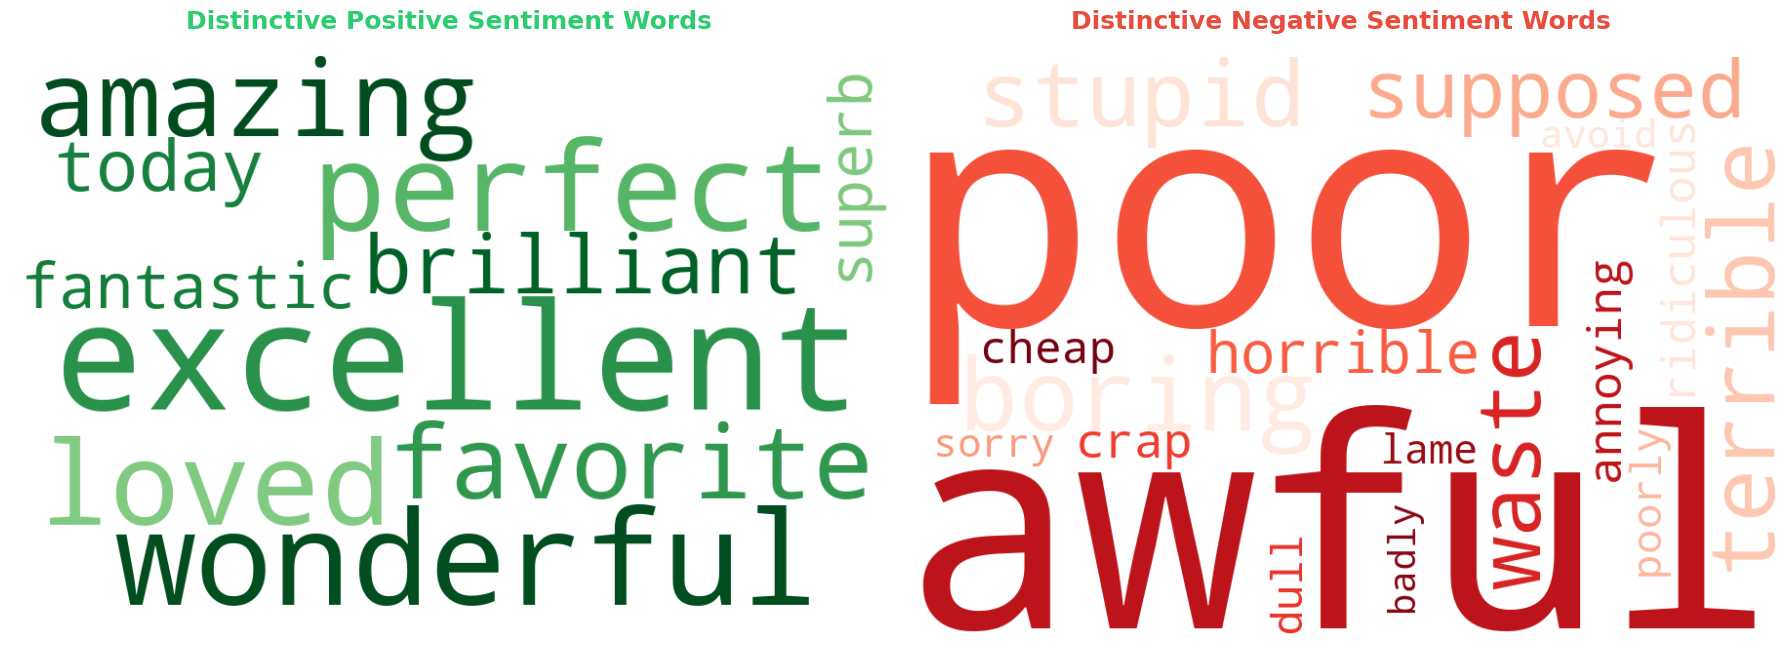


CREATING COMPARISON CHARTS
✓ Saved: 'distinctive_words_comparison_v3.png'


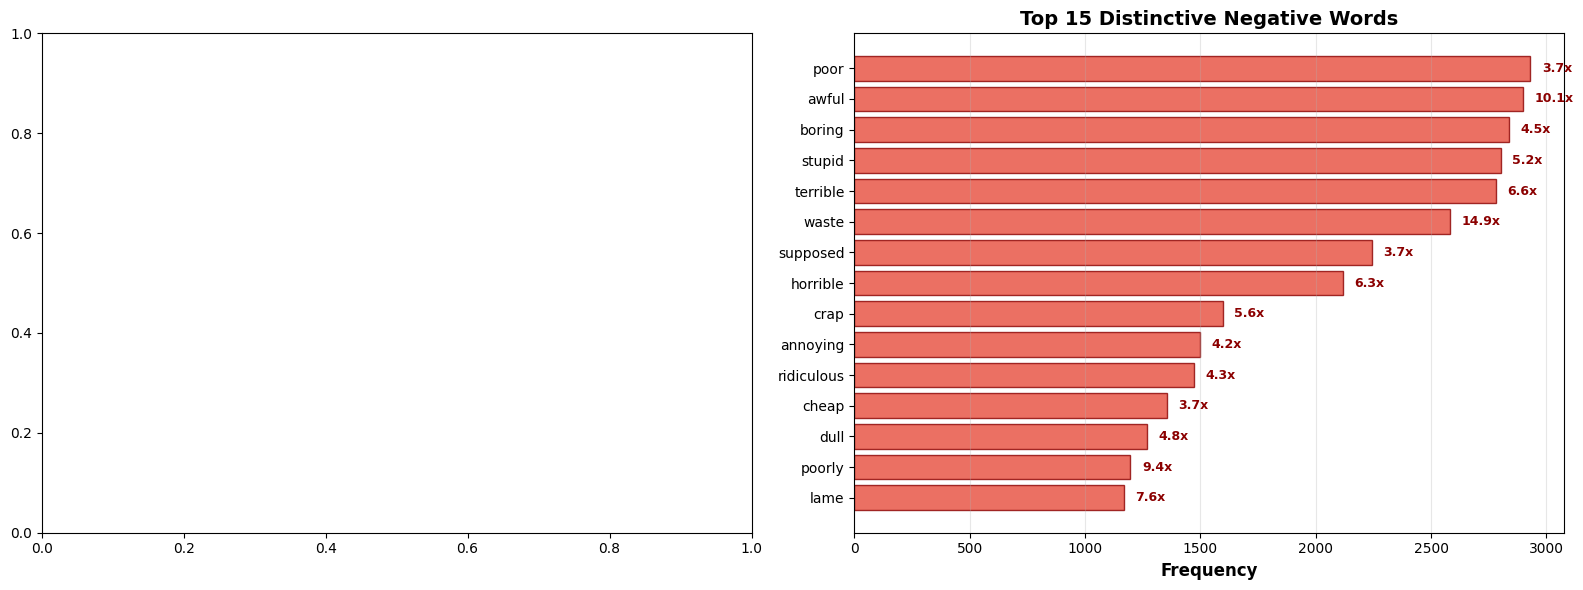


COMPLETE!

Created visualizations focusing ONLY on words that are:
• At least 3x more common in one sentiment
• Appear at least 100 times
• Are at least 4 letters long
• Not in the comprehensive stop word list

These are TRUE sentiment indicators!

Files:
✓ sentiment_word_clouds_v3.png
✓ distinctive_words_comparison_v3.png



In [70]:
"""
Best Word Cloud - Sentiment Words Only
=======================================

Focus ONLY on emotion/opinion words that actually indicate sentiment
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re


# ==================== SUPER COMPREHENSIVE STOP WORDS ====================

# Massive stop word list to filter everything except sentiment words
stop_words = {
    # All pronouns
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 
    'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 
    'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 
    'themselves', 'who', 'whom', 'whose', 'which', 'what', 'where', 'when', 'why', 
    'how', 'this', 'that', 'these', 'those',
    
    # All common verbs
    'is', 'am', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 
    'having', 'do', 'does', 'did', 'doing', 'will', 'would', 'should', 'could', 
    'may', 'might', 'must', 'can', 'shall', 'go', 'goes', 'going', 'went', 'gone',
    'make', 'makes', 'making', 'made', 'get', 'gets', 'getting', 'got', 'gotten',
    'see', 'sees', 'seeing', 'saw', 'seen', 'look', 'looks', 'looking', 'looked',
    'come', 'comes', 'coming', 'came', 'take', 'takes', 'taking', 'took', 'taken',
    'know', 'knows', 'knowing', 'knew', 'known', 'think', 'thinks', 'thinking',
    'thought', 'give', 'gives', 'giving', 'gave', 'given', 'find', 'finds',
    'finding', 'found', 'tell', 'tells', 'telling', 'told', 'become', 'becomes',
    'becoming', 'became', 'leave', 'leaves', 'leaving', 'left', 'feel', 'feels',
    'feeling', 'felt', 'try', 'tries', 'trying', 'tried', 'ask', 'asks', 'asking',
    'asked', 'work', 'works', 'working', 'worked', 'seem', 'seems', 'seeming',
    'seemed', 'want', 'wants', 'wanting', 'wanted', 'show', 'shows', 'showing',
    'showed', 'shown', 'watch', 'watches', 'watching', 'watched', 'play', 'plays',
    'playing', 'played', 'turn', 'turns', 'turning', 'turned', 'put', 'puts',
    'putting', 'keep', 'keeps', 'keeping', 'kept', 'let', 'lets', 'letting',
    'begin', 'begins', 'beginning', 'began', 'begun', 'run', 'runs', 'running', 'ran',
    'bring', 'brings', 'bringing', 'brought', 'happen', 'happens', 'happening',
    'happened', 'write', 'writes', 'writing', 'wrote', 'written', 'sit', 'sits',
    'sitting', 'sat', 'stand', 'stands', 'standing', 'stood', 'lose', 'loses',
    'losing', 'lost', 'pay', 'pays', 'paying', 'paid', 'meet', 'meets', 'meeting',
    'met', 'include', 'includes', 'including', 'included', 'continue', 'continues',
    'continuing', 'continued', 'set', 'sets', 'setting', 'learn', 'learns',
    'learning', 'learned', 'learnt', 'change', 'changes', 'changing', 'changed',
    'lead', 'leads', 'leading', 'led', 'understand', 'understands', 'understanding',
    'understood', 'live', 'lives', 'living', 'lived', 'believe', 'believes',
    'believing', 'believed', 'hold', 'holds', 'holding', 'held', 'stay', 'stays',
    'staying', 'stayed', 'hear', 'hears', 'hearing', 'heard', 'appear', 'appears',
    'appearing', 'appeared', 'buy', 'buys', 'buying', 'bought', 'wait', 'waits',
    'waiting', 'waited', 'serve', 'serves', 'serving', 'served', 'die', 'dies',
    'dying', 'died', 'send', 'sends', 'sending', 'sent', 'expect', 'expects',
    'expecting', 'expected', 'build', 'builds', 'building', 'built', 'fall',
    'falls', 'falling', 'fell', 'fallen', 'cut', 'cuts', 'cutting', 'reach',
    'reaches', 'reaching', 'reached', 'kill', 'kills', 'killing', 'killed',
    'remain', 'remains', 'remaining', 'remained', 'suggest', 'suggests',
    'suggesting', 'suggested', 'raise', 'raises', 'raising', 'raised',
    
    # Articles, conjunctions, prepositions
    'the', 'a', 'an', 'and', 'or', 'but', 'if', 'because', 'as', 'until', 'while',
    'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up',
    'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then',
    'once', 'here', 'there', 'all', 'both', 'each', 'few', 'more', 'most', 'other',
    'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too',
    'very', 'just', 'now', 'also', 'still', 'however', 'though', 'although',
    
    # Numbers and determiners
    'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
    'first', 'second', 'third', 'last', 'next', 'many', 'much', 'little', 'lot',
    
    # Movie-specific but non-sentiment words
    'movie', 'film', 'movies', 'films', 'plot', 'story', 'character', 'characters',
    'scene', 'scenes', 'acting', 'actor', 'actors', 'actress', 'actresses',
    'director', 'directors', 'cast', 'role', 'roles', 'series', 'episode',
    'episodes', 'season', 'seasons', 'script', 'screenplay', 'cinema', 'theatre',
    'theater', 'screen', 'production', 'dvd', 'video', 'videos', 'minute', 'minutes',
    'hour', 'hours', 'time', 'times', 'end', 'ending', 'start', 'beginning',
    'watched', 'watching', 'watch', 'seen', 'seeing', 'view', 'viewing',
    
    # Generic words
    'thing', 'things', 'something', 'anything', 'everything', 'nothing', 'someone',
    'anyone', 'everyone', 'way', 'ways', 'part', 'parts', 'point', 'points', 'fact',
    'facts', 'case', 'cases', 'world', 'life', 'day', 'days', 'year', 'years',
    'people', 'person', 'man', 'men', 'woman', 'women', 'guy', 'guys', 'girl',
    'girls', 'boy', 'boys', 'kid', 'kids', 'child', 'children', 'family', 'friend',
    'friends', 'line', 'lines', 'moment', 'moments', 'probably', 'perhaps', 'maybe',
    'actually', 'really', 'quite', 'rather', 'pretty', 'fairly', 'especially',
    'particularly', 'simply', 'certainly', 'definitely', 'absolutely', 'totally',
    'completely', 'entirely', 'exactly', 'truly', 'indeed', 'sure', 'course',
    'well', 'better', 'best', 'least', 'worse', 'worst',  # Remove these generic comparatives
    'enough', 'several', 'various', 'different', 'certain', 'whole', 'entire',
    'real', 'true', 'new', 'old', 'young', 'long', 'short', 'big', 'small', 'large',
    'little', 'high', 'low', 'great', 'good',  # Remove generic good/great
    'makes', 'into', 'while', 'theres', 'doesnt', 'dont', 'cant', 'wont', 'isnt',
    'wasnt', 'arent', 'werent', 'hasnt', 'havent', 'hadnt', 'didnt', 'wouldnt',
    'shouldnt', 'couldnt', 'mightnt', 'mustnt', 'neednt',
    'ever', 'never', 'always', 'often', 'sometimes', 'usually', 'rarely', 'hardly',
    'barely', 'nearly', 'almost', 'quite', 'fairly', 'rather', 'instead', 'yet',
    'already', 'ago', 'later', 'soon', 'early', 'late', 'far', 'near', 'close',
    'away', 'back', 'forward', 'together', 'apart', 'around', 'throughout',
    'throughout', 'anywhere', 'everywhere', 'nowhere', 'somewhere', 'somehow',
    'anyway', 'anyhow', 'otherwise', 'therefore', 'thus', 'hence', 'accordingly',
    'consequently', 'moreover', 'furthermore', 'nevertheless', 'nonetheless',
    'regardless', 'besides', 'likewise', 'similarly', 'conversely', 'alternatively'
}

print("=" * 70)
print("SENTIMENT-FOCUSED WORD CLOUDS")
print("=" * 70)
print(f"\n✓ Using {len(stop_words)} stop words")
print("✓ Focusing on emotion and opinion words only")


# ==================== LOAD DATA ====================

positive_reviews = df[df['sentiment'] == 'positive']['cleaned_review']
negative_reviews = df[df['sentiment'] == 'negative']['cleaned_review']

positive_text = ' '.join(positive_reviews.astype(str))
negative_text = ' '.join(negative_reviews.astype(str))


# ==================== FIND TRULY DISTINCTIVE WORDS ====================

print("\n" + "=" * 70)
print("ANALYZING DISTINCTIVE SENTIMENT WORDS")
print("=" * 70)

# Get words (minimum 4 letters for meaningful words)
pos_words = [w for w in positive_text.split() if w.lower() not in stop_words and len(w) >= 4]
neg_words = [w for w in negative_text.split() if w.lower() not in stop_words and len(w) >= 4]

pos_counter = Counter(pos_words)
neg_counter = Counter(neg_words)

# Find HIGHLY distinctive words (at least 3x more common in one sentiment)
distinctive_positive = []
for word, count in pos_counter.most_common(200):
    neg_count = neg_counter.get(word, 1)
    ratio = count / neg_count
    if ratio >= 3.0 and count > 100:  # Much stricter criteria
        distinctive_positive.append((word, count, ratio))

distinctive_negative = []
for word, count in neg_counter.most_common(200):
    pos_count = pos_counter.get(word, 1)
    ratio = count / pos_count
    if ratio >= 3.0 and count > 100:
        distinctive_negative.append((word, count, ratio))

print(f"\nFound {len(distinctive_positive)} distinctive POSITIVE words")
print(f"Found {len(distinctive_negative)} distinctive NEGATIVE words")

# Show top words
print("\nTop 20 distinctive POSITIVE words:")
for i, (word, count, ratio) in enumerate(distinctive_positive[:20], 1):
    print(f"  {i:2d}. {word:15s} - {count:,} times ({ratio:.1f}x)")

print("\nTop 20 distinctive NEGATIVE words:")
for i, (word, count, ratio) in enumerate(distinctive_negative[:20], 1):
    print(f"  {i:2d}. {word:15s} - {count:,} times ({ratio:.1f}x)")


# ==================== CREATE WORD CLOUDS FROM DISTINCTIVE WORDS ONLY ====================

print("\n" + "=" * 70)
print("CREATING WORD CLOUDS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Create text from ONLY distinctive words (weighted by frequency)
pos_words_repeated = []
for word, count, _ in distinctive_positive:
    pos_words_repeated.extend([word] * count)
pos_distinctive_text = ' '.join(pos_words_repeated)

neg_words_repeated = []
for word, count, _ in distinctive_negative:
    neg_words_repeated.extend([word] * count)
neg_distinctive_text = ' '.join(neg_words_repeated)

# Positive word cloud
print("\nCreating POSITIVE sentiment word cloud...")
if len(pos_distinctive_text) > 0:
    wordcloud_pos = WordCloud(
        width=900,
        height=600,
        background_color='white',
        colormap='Greens',
        max_words=40,
        relative_scaling=0.6,
        min_font_size=14,
        prefer_horizontal=0.7,
        collocations=False
    ).generate(pos_distinctive_text)
    
    axes[0].imshow(wordcloud_pos, interpolation='bilinear')
    axes[0].set_title('Distinctive Positive Sentiment Words', 
                     fontsize=18, fontweight='bold', color='#2ecc71', pad=20)
    axes[0].axis('off')
    print("✓ Positive word cloud created")
else:
    axes[0].text(0.5, 0.5, 'Not enough distinctive words', 
                ha='center', va='center', fontsize=16)
    axes[0].axis('off')

# Negative word cloud
print("Creating NEGATIVE sentiment word cloud...")
if len(neg_distinctive_text) > 0:
    wordcloud_neg = WordCloud(
        width=900,
        height=600,
        background_color='white',
        colormap='Reds',
        max_words=40,
        relative_scaling=0.6,
        min_font_size=14,
        prefer_horizontal=0.7,
        collocations=False
    ).generate(neg_distinctive_text)
    
    axes[1].imshow(wordcloud_neg, interpolation='bilinear')
    axes[1].set_title('Distinctive Negative Sentiment Words', 
                     fontsize=18, fontweight='bold', color='#e74c3c', pad=20)
    axes[1].axis('off')
    print("✓ Negative word cloud created")
else:
    axes[1].text(0.5, 0.5, 'Not enough distinctive words', 
                ha='center', va='center', fontsize=16)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('sentiment_word_clouds_v3.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n✓ Saved: 'sentiment_word_clouds_v3.png'")
plt.show()


# ==================== BAR CHART OF DISTINCTIVE WORDS ====================

print("\n" + "=" * 70)
print("CREATING COMPARISON CHARTS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive
if len(distinctive_positive) >= 15:
    words, counts, ratios = zip(*distinctive_positive[:15])
    axes[0].barh(words, counts, color='#2ecc71', alpha=0.8, edgecolor='darkgreen')
    axes[0].set_xlabel('Frequency', fontweight='bold', fontsize=12)
    axes[0].set_title('Top 15 Distinctive Positive Words', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Add ratio annotations
    for i, (word, count, ratio) in enumerate(zip(words, counts, ratios)):
        axes[0].text(count + 50, i, f'{ratio:.1f}x', 
                    va='center', fontsize=9, color='darkgreen', fontweight='bold')

# Negative  
if len(distinctive_negative) >= 15:
    words, counts, ratios = zip(*distinctive_negative[:15])
    axes[1].barh(words, counts, color='#e74c3c', alpha=0.8, edgecolor='darkred')
    axes[1].set_xlabel('Frequency', fontweight='bold', fontsize=12)
    axes[1].set_title('Top 15 Distinctive Negative Words', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)
    
    # Add ratio annotations
    for i, (word, count, ratio) in enumerate(zip(words, counts, ratios)):
        axes[1].text(count + 50, i, f'{ratio:.1f}x', 
                    va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('distinctive_words_comparison_v3.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 'distinctive_words_comparison_v3.png'")
plt.show()


print("\n" + "=" * 70)
print("COMPLETE!")
print("=" * 70)
print("""
Created visualizations focusing ONLY on words that are:
• At least 3x more common in one sentiment
• Appear at least 100 times
• Are at least 4 letters long
• Not in the comprehensive stop word list

These are TRUE sentiment indicators!

Files:
✓ sentiment_word_clouds_v3.png
✓ distinctive_words_comparison_v3.png
""")


CREATING CONFUSION MATRIX GRID

✓ Saved: 'all_4methods_confusion_matrices.png'


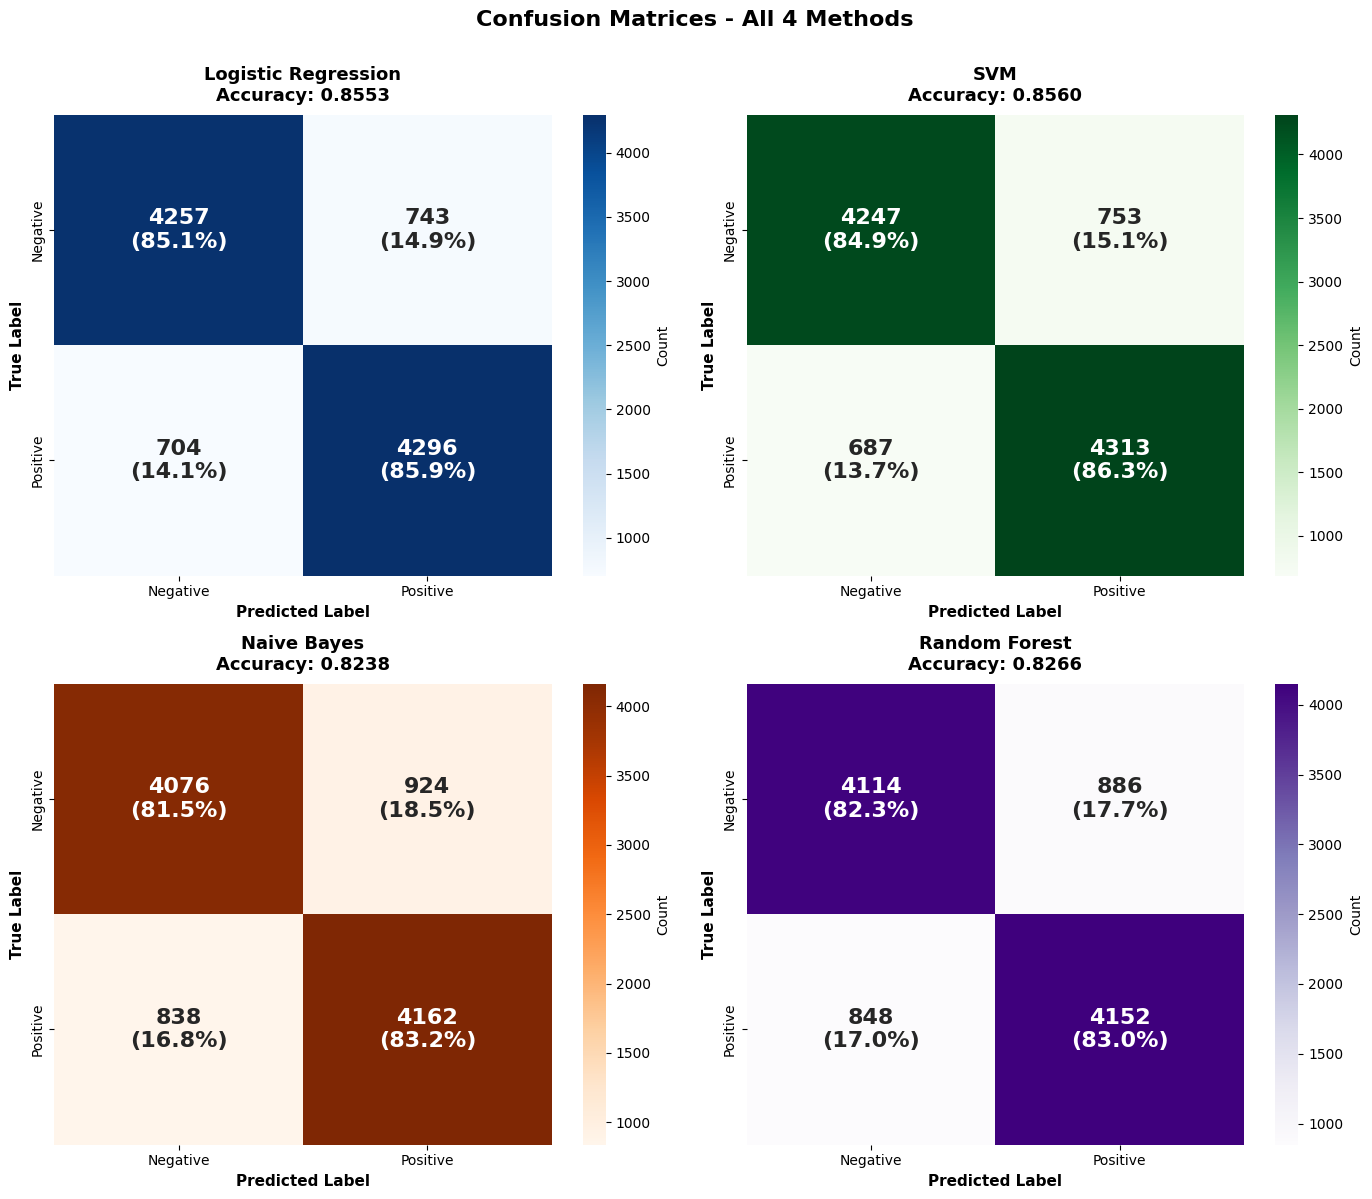


COMPLETE!

Created 2×2 confusion matrix grid showing:
• Logistic Regression (top-left, blue)
• Naive Bayes (top-right, red)
• Random Forest (bottom-left, green)
• SVM (bottom-right, orange)

Each matrix shows:
• Count and percentage for each cell
• True vs Predicted labels
• Overall accuracy in the title

File: all_4methods_confusion_matrices.png



In [77]:

# ==================== CREATE 2x2 CONFUSION MATRIX GRID ====================

print("\n" + "=" * 70)
print("CREATING CONFUSION MATRIX GRID")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

method_names = ['Logistic Regression','SVM', 'Naive Bayes', 'Random Forest' ]
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for idx, (method, cmap) in enumerate(zip(method_names, cmaps)):
    ax = axes[idx]
    cm = results[method]['confusion_matrix']
    
    # Calculate percentages per row
    cm_percentages = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    
    # Create labels with both count and percentage
    labels = np.array([[f'{count}\n({percent:.1f}%)' 
                       for count, percent in zip(row_counts, row_percents)]
                      for row_counts, row_percents in zip(cm, cm_percentages)])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap, ax=ax,
               xticklabels=['Negative', 'Positive'],
               yticklabels=['Negative', 'Positive'],
               annot_kws={'size': 16, 'weight': 'bold'},
               cbar_kws={'label': 'Count'})
    
    acc = results[method]['accuracy']
    ax.set_title(f'{method}\nAccuracy: {acc:.4f}', fontweight='bold', fontsize=13, pad=10)
    ax.set_ylabel('True Label', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices - All 4 Methods', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('all_4methods_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 'all_4methods_confusion_matrices.png'")
plt.show()


# ==================== SUMMARY ====================

print("\n" + "=" * 70)
print("COMPLETE!")
print("=" * 70)
print("""
Created 2×2 confusion matrix grid showing:
• Logistic Regression (top-left, blue)
• Naive Bayes (top-right, red)
• Random Forest (bottom-left, green)
• SVM (bottom-right, orange)

Each matrix shows:
• Count and percentage for each cell
• True vs Predicted labels
• Overall accuracy in the title

File: all_4methods_confusion_matrices.png
""")